In [40]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import datetime


In [41]:
#Read the file and pick the specific sheet that I want 
excelSheet = pd.ExcelFile('/Users/preciousajilore/Documents/GitHub/torchmtlr/notebooks/first_cleaned.xlsx')
print(excelSheet.sheet_names)

df = pd.read_excel(
                  excelSheet,         #  name of the excel file
                  sheet_name='Sheet1', #   name of the sheet you want to read
                  engine='openpyxl')

['Sheet1']


In [42]:
df["ER visits"]

0       yes
1        No
2        no
3        no
4       yes
       ... 
1982      0
1983    NaN
1984    NaN
1985      0
1986    NaN
Name: ER visits, Length: 1987, dtype: object

In [43]:
print(df["ER visits"].unique())

['yes' 'No' 'no'
 'yes(hematoma,celulitis of the penis,urethrocutaneous fistula)'
 'no (yes for CP/GERD at just under 90d)' 'Yes'
 'Yes - post op wound pain, uncomplicated, no infection' 'yes - UTI'
 'Yes, pre-op' 'No (only pre-op x 1)' 'yes - wound infection' nan
 'Yes, for irrigation of foley'
 'Yes (for wound dehissance and perineal pain 13 days post-op)'
 'Yes (pre-op, not post op)' 'Yes (for donor site pain)'
 'Yes (for dehiscence)' 'Yes (gross hematuria after 5 mo cysto)'
 'Yes - UC fistula from SPC site' 'Yes (for wound infection)'
 'Yes (right epididymitis)' 'Yes - UTI; thigh abscess' 'yes - retention'
 'Yes (hematuria/retention)' 'Unknown' 'yes (perioperatively)'
 'yes (not tolerating cipro)' 'ER visit before BUR' 'yes (infection)' 0 1]


In [44]:
def clean_er_visits(val):
    if pd.isnull(val):
        return 0
    v = str(val).strip().lower()
    if v.startswith('yes'):
        return 1
    if v.startswith('no'):
        return 0
    if v == "1":
        return 1
    if v == "0":
        return 0
    return 0

In [45]:
df["ER visits"] = df["ER visits"].apply(clean_er_visits).astype(int)

In [46]:
print(df["ER visits"].unique())

[1 0]


In [47]:
df.columns

Index(['Age_calc', 'Date of Surgery', 'COPD', 'Diabetes', 'COPD.1', 'Smoker',
       'Abx', 'Transection', 'Failure', 'fu', 'datetofailureorfollowup',
       'ER visits', 'UTI  Post', 'UTI  recurring', 'foley', 'failure date'],
      dtype='object')

In [48]:
num_failures = (df["Failure"] == 1).sum()
print(num_failures)

176


In [49]:
print(df["failure date"].unique())

[nan datetime.datetime(2015, 5, 19, 0, 0)
 datetime.datetime(2004, 11, 16, 0, 0)
 datetime.datetime(2010, 11, 10, 0, 0)
 datetime.datetime(2007, 3, 14, 0, 0) datetime.datetime(2016, 1, 1, 0, 0)
 datetime.datetime(2022, 1, 12, 0, 0)
 datetime.datetime(2020, 11, 16, 0, 0) datetime.datetime(2020, 9, 9, 0, 0)
 'died 7-4-22' datetime.datetime(2021, 4, 16, 0, 0)
 datetime.datetime(2021, 8, 5, 0, 0) datetime.datetime(2022, 4, 6, 0, 0)
 'died 26-3-22' datetime.datetime(2021, 12, 2, 0, 0)
 datetime.datetime(2024, 6, 3, 0, 0) datetime.datetime(2022, 12, 14, 0, 0)
 datetime.datetime(2022, 3, 24, 0, 0) datetime.datetime(2022, 6, 15, 0, 0)
 datetime.datetime(2023, 7, 14, 0, 0) datetime.datetime(2023, 1, 4, 0, 0)
 datetime.datetime(2022, 7, 28, 0, 0) datetime.datetime(2023, 5, 18, 0, 0)
 datetime.datetime(2022, 7, 27, 0, 0) datetime.datetime(2023, 3, 7, 0, 0)
 datetime.datetime(2022, 11, 3, 0, 0)
 datetime.datetime(2022, 11, 30, 0, 0)
 datetime.datetime(2022, 11, 16, 0, 0) datetime.datetime(2023, 1,

In [36]:
#clean failure date
def clean_failure_date(val):
    #check nan vals
    if pd.isnull(val) or val == 0:
        return pd.NaT
    if isinstance(val, (pd.Timestamp, datetime.datetime)):
        return val
    #deal with the ones that say died or sum like that
    if isinstance(val, str):
        if 'died' in val.lower():
            #try and exttract the date
            date_match = re.search(r'\d{1,2}/\d{1,2}/\d{4}', val)
            if date_match:
                date_str = date_match.group(1)
                try:
                    dt = pd.to_datetime(date_str, dayfirst=True, errors='coerce')
                    return dt
                except:
                    return pd.NaT
        else:
                return pd.NaT
    else:
        return pd.to_datetime(val, errors='coerce')
    
    return pd.NaT

In [50]:
df["failure date"] = df["failure date"].apply(clean_failure_date)


In [51]:
df["failure date"].value_counts()

failure date
2015-05-19    1
2023-05-18    1
2023-03-07    1
2022-11-03    1
2022-11-30    1
2022-11-16    1
2023-01-03    1
2023-01-11    1
2023-01-26    1
2023-04-06    1
2024-04-17    1
2023-03-24    1
2023-05-04    1
2023-08-23    1
2023-12-08    1
2023-11-29    1
2023-12-13    1
2022-07-27    1
2022-07-28    1
2004-11-16    1
2023-01-04    1
2010-11-10    1
2007-03-14    1
2016-01-01    1
2022-01-12    1
2020-11-16    1
2020-09-09    1
2021-04-16    1
2021-08-05    1
2022-04-06    1
2021-12-02    1
2024-06-03    1
2022-12-14    1
2022-03-24    1
2022-06-15    1
2023-07-14    1
2023-11-28    1
Name: count, dtype: int64

In [52]:
print(df["Date of Surgery"].unique())

<DatetimeArray>
['2003-08-05 00:00:00', '2003-08-06 00:00:00', '2003-08-21 00:00:00',
 '2003-08-28 00:00:00', '2003-09-29 00:00:00', '2003-10-23 00:00:00',
 '2003-11-10 00:00:00', '2003-11-24 00:00:00', '2003-12-08 00:00:00',
 '2004-01-05 00:00:00',
 ...
 '2024-01-23 00:00:00', '2024-01-25 00:00:00', '2024-02-02 00:00:00',
 '2024-02-06 00:00:00', '2024-02-09 00:00:00', '2024-02-12 00:00:00',
 '2024-02-14 00:00:00', '2024-02-23 00:00:00', '2024-02-26 00:00:00',
 '2024-03-18 00:00:00']
Length: 1038, dtype: datetime64[ns]


In [53]:
print(df["fu"].unique())

[datetime.datetime(2017, 9, 8, 0, 0) datetime.datetime(2010, 8, 12, 0, 0)
 nan datetime.datetime(2015, 5, 19, 0, 0)
 datetime.datetime(2011, 5, 4, 0, 0) datetime.datetime(2004, 11, 16, 0, 0)
 datetime.datetime(2019, 4, 5, 0, 0) datetime.datetime(2004, 6, 24, 0, 0)
 datetime.datetime(2015, 5, 5, 0, 0) datetime.datetime(2010, 11, 9, 0, 0)
 datetime.datetime(2017, 10, 5, 0, 0) datetime.datetime(2015, 9, 16, 0, 0)
 datetime.datetime(2006, 3, 1, 0, 0) datetime.datetime(2013, 6, 7, 0, 0)
 datetime.datetime(2011, 12, 6, 0, 0) datetime.datetime(2005, 8, 2, 0, 0)
 datetime.datetime(2017, 11, 23, 0, 0)
 datetime.datetime(2010, 4, 27, 0, 0) datetime.datetime(2007, 9, 26, 0, 0)
 datetime.datetime(2008, 11, 24, 0, 0)
 datetime.datetime(2018, 5, 17, 0, 0) datetime.datetime(2008, 2, 13, 0, 0)
 datetime.datetime(2008, 3, 12, 0, 0) datetime.datetime(2004, 8, 24, 0, 0)
 datetime.datetime(2010, 7, 22, 0, 0) datetime.datetime(2018, 7, 3, 0, 0)
 datetime.datetime(2008, 11, 19, 0, 0) datetime.datetime(2013,

In [54]:
# Convert 'fu' to datetime, errors become NaT (pandas' datetime missing value)
df["fu"] = pd.to_datetime(df["fu"], errors='coerce')


In [59]:
print(df["Date of Surgery"].describe())

count                             1987
mean     2015-05-05 02:09:43.392048384
min                2003-08-05 00:00:00
25%                2010-11-22 00:00:00
50%                2016-01-11 00:00:00
75%                2019-11-14 00:00:00
max                2024-03-18 00:00:00
Name: Date of Surgery, dtype: object


In [60]:
#drop empty rows
df_clean = df.dropna(subset=['Date of Surgery', "fu"])

In [61]:
df_clean["time_to_event"] = (df_clean["fu"] - df_clean["Date of Surgery"]).dt.days  #days


/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_65643/3632361703.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["time_to_event"] = (df_clean["fu"] - df_clean["Date of Surgery"]).dt.days  #days


In [63]:
print(df_clean["fu"].unique())

<DatetimeArray>
['2017-09-08 00:00:00', '2010-08-12 00:00:00', '2015-05-19 00:00:00',
 '2011-05-04 00:00:00', '2004-11-16 00:00:00', '2019-04-05 00:00:00',
 '2004-06-24 00:00:00', '2015-05-05 00:00:00', '2010-11-09 00:00:00',
 '2017-10-05 00:00:00',
 ...
 '2024-03-06 00:00:00', '2024-06-07 00:00:00', '2024-04-10 00:00:00',
 '2024-03-21 00:00:00', '2024-06-11 00:00:00', '2024-06-12 00:00:00',
 '2024-05-15 00:00:00', '2024-05-29 00:00:00', '2024-06-13 00:00:00',
 '2024-04-16 00:00:00']
Length: 823, dtype: datetime64[ns]


In [67]:
print(df_clean["time_to_event"].describe())
print(df_clean[df_clean["time_to_event"] < 0][["Date of Surgery", "fu", "time_to_event"]])


count    1761.000000
mean      640.568427
std       862.256399
min         0.000000
25%       163.000000
50%       365.000000
75%       641.000000
max      5889.000000
Name: time_to_event, dtype: float64
Empty DataFrame
Columns: [Date of Surgery, fu, time_to_event]
Index: []


In [71]:
df_clean.columns

Index(['Age_calc', 'Date of Surgery', 'COPD', 'Diabetes', 'COPD.1', 'Smoker',
       'Abx', 'Transection', 'Failure', 'fu', 'datetofailureorfollowup',
       'ER visits', 'UTI  Post', 'UTI  recurring', 'foley', 'failure date',
       'time_to_event'],
      dtype='object')

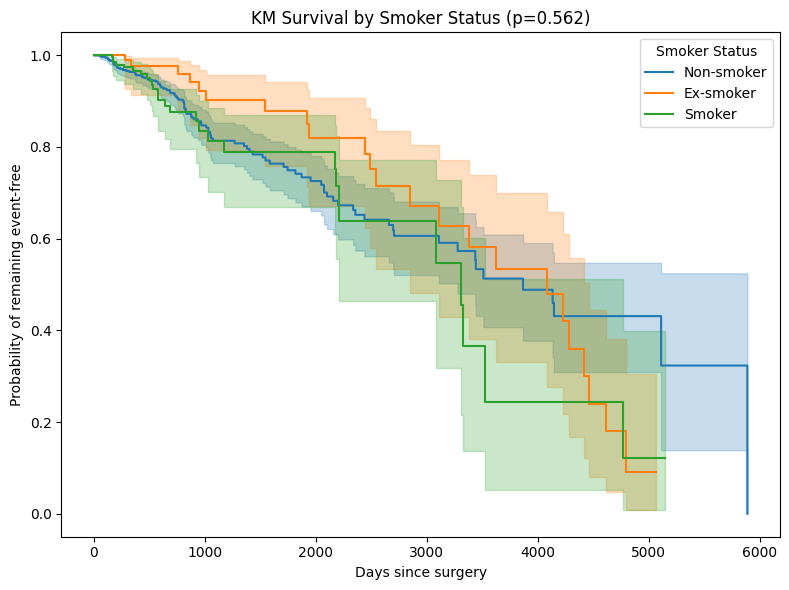

In [73]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from lifelines.statistics import multivariate_logrank_test


kmf = KaplanMeierFitter()

#mapping smoker_status is numeric
smoker_map = {0: "Non-smoker", 1: "Ex-smoker", 2: "Smoker"}
# Remove the mapping if already strings

plt.figure(figsize=(8,6))

for label, group in df_clean.groupby("Smoker"):
    # For nicer legend if numeric:
    legend_label = smoker_map[label] if label in smoker_map else str(label)
    kmf.fit(group["time_to_event"], group["Failure"], label=legend_label)
    kmf.plot_survival_function(ci_show=True)  # ci_show adds confidence intervals

results = multivariate_logrank_test(df_clean["time_to_event"], df_clean["Smoker"], df_clean["Failure"])
plt.xlabel("Days since surgery")
plt.ylabel("Probability of remaining event-free")
plt.title(f"KM Survival by Smoker Status (p={results.p_value:.3g})")
plt.legend(title="Smoker Status")
plt.tight_layout()
plt.show()